# 📈 Yield Prediction — Model Selection
**Task :** Regression — predict `Yield` (kg/ha) from State, District, Crop, Season, Year, Area  
**Data :** `yield_train.csv` / `yield_test.csv` (processed)  
**Notebook :** `05_yield_model_selection.ipynb`

### Strategy
| Step | Detail |
|------|--------|
| Encoding | `OrdinalEncoder` for categorical features |
| Target transform | `log1p(Yield)` — right-skewed (found in EDA), inversed for metrics |
| Selection | 5-fold KFold CV on **train set** → compare RMSE, MAE, R² |
| Models | Linear Regression · Ridge · Lasso · Decision Tree · Random Forest · Extra Trees · Gradient Boosting · XGBoost · LightGBM |
| Final eval | Best model evaluated on held-out **test set** |
| Output | `yield_model_selection_summary.txt` written to `../outputs/` |

## 1. Imports & Setup

In [1]:
import os, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
warnings.filterwarnings('ignore')

from sklearn.preprocessing   import OrdinalEncoder
from sklearn.model_selection import KFold, cross_validate
from sklearn.metrics         import (
    mean_absolute_error, mean_squared_error, r2_score
)

# Regressors
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree         import DecisionTreeRegressor
from sklearn.ensemble     import (
    RandomForestRegressor, ExtraTreesRegressor,
    GradientBoostingRegressor
)
try:
    from xgboost  import XGBRegressor
    XGB_AVAILABLE = True
except ImportError:
    XGB_AVAILABLE = False
    print('⚠️  xgboost not installed — skipping')

try:
    from lightgbm import LGBMRegressor
    LGB_AVAILABLE = True
except ImportError:
    LGB_AVAILABLE = False
    print('⚠️  lightgbm not installed — skipping')

# Dark plot theme
plt.rcParams.update({
    'figure.facecolor': '#0f0f1a', 'axes.facecolor': '#1a1a2e',
    'axes.edgecolor': '#333355',   'axes.labelcolor': '#e0e0f0',
    'text.color': '#e0e0f0',       'xtick.color': '#a0a0c0',
    'ytick.color': '#a0a0c0',      'grid.color': '#2a2a4a',
    'grid.linestyle': '--',        'grid.alpha': 0.5,
    'font.size': 11,
})
ACCENT = '#7c3aed'; ACCENT2 = '#06b6d4'; HIGHLIGHT = '#f59e0b'
GREEN  = '#10b981'; RED = '#f43f5e'
RANDOM_STATE = 42
print('Setup complete')

Setup complete


## 2. Load Data

In [2]:
train = pd.read_csv('../data/processed/yield_train.csv')
test  = pd.read_csv('../data/processed/yield_test.csv')

print(f'Train : {train.shape}   Test : {test.shape}')
print(f'Columns : {list(train.columns)}')
print(f'Yield stats:\n{train["Yield"].describe().round(2)}')
train.head()

Train : (271481, 7)   Test : (67871, 7)
Columns : ['State', 'District', 'Crop', 'Year', 'Season', 'Yield', 'Crop_Category']
Yield stats:
count    271481.00
mean         81.31
std         928.57
min           0.01
25%           0.57
50%           1.03
75%           2.51
max       43958.33
Name: Yield, dtype: float64


,State,District,Crop,Year,Season,Yield,Crop_Category
0,Rajasthan,Chittorgarh,Moong(Green Gram),2018,Kharif,0.50,Pulses
1,Gujarat,Rajkot,Other Kharif pulses,2003,Kharif,0.33,Pulses
2,Andhra Pradesh,Prakasam,Cowpea(Lobia),2014,Rabi,1.28,Pulses
3,Andhra Pradesh,Karimnagar,Cotton(lint),2004,Kharif,1.25,Fiber Crops
4,Karnataka,Bangalorerural,Ragi,1999,Kharif,2.06,Cereals


## 3. Feature Engineering & Encoding

In [3]:
CAT_FEATURES = ['State', 'District', 'Crop', 'Crop_Category', 'Season']
NUM_FEATURES = ['Year',]
FEATURES     = CAT_FEATURES + NUM_FEATURES
TARGET       = 'Yield'

# Ordinal-encode categoricals
enc = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
enc.fit(train[CAT_FEATURES])

def prepare(df, encoder):
    X_cat = encoder.transform(df[CAT_FEATURES])
    X_num = df[NUM_FEATURES].values
    X     = np.hstack([X_cat, X_num])
    y     = df[TARGET].values
    return X, y

X_train, y_train = prepare(train, enc)
X_test,  y_test  = prepare(test,  enc)

# Log-transform target (EDA showed heavy right skew)
y_train_log = np.log1p(y_train)
y_test_log  = np.log1p(y_test)

print(f'X_train : {X_train.shape}   X_test : {X_test.shape}')
print(f'y_train log → mean={y_train_log.mean():.3f}, std={y_train_log.std():.3f}')

X_train : (271481, 6)   X_test : (67871, 6)
y_train log → mean=1.099, std=1.159


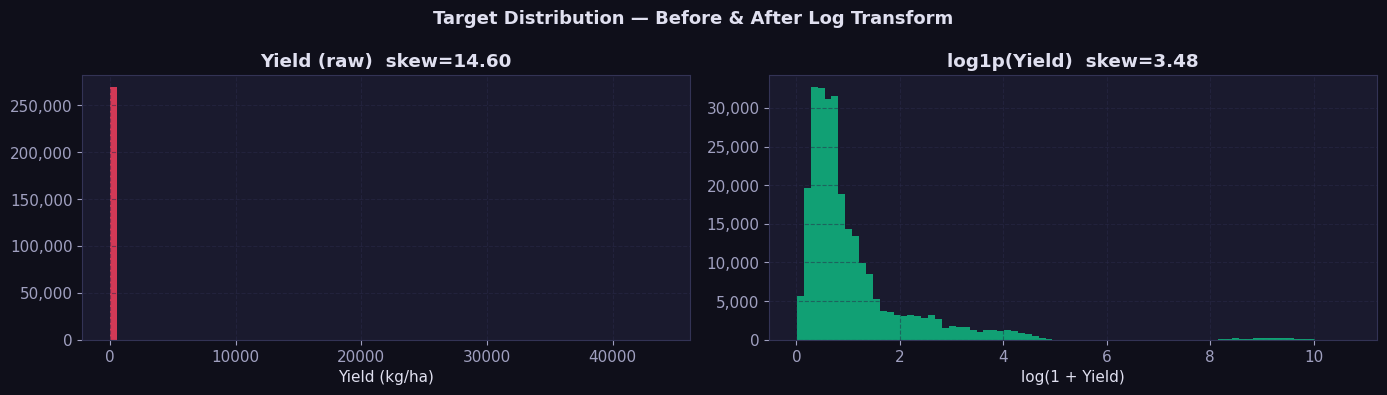

In [4]:
# Verify log transform improves normality
from scipy import stats
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(y_train,     bins=80, color=RED,    edgecolor='none', alpha=0.85)
axes[0].set_title(f'Yield (raw)  skew={stats.skew(y_train):.2f}', fontweight='bold')
axes[0].set_xlabel('Yield (kg/ha)')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

axes[1].hist(y_train_log, bins=80, color=GREEN,  edgecolor='none', alpha=0.85)
axes[1].set_title(f'log1p(Yield)  skew={stats.skew(y_train_log):.2f}', fontweight='bold')
axes[1].set_xlabel('log(1 + Yield)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

[ax.grid(True) for ax in axes]
fig.suptitle('Target Distribution — Before & After Log Transform', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 4. Custom CV Scorer (metrics in original scale)

In [5]:
from sklearn.model_selection import KFold

def cv_evaluate(model, X, y_log, cv, name=''):
    """Run KFold CV; compute metrics in ORIGINAL scale via expm1."""
    rmse_list, mae_list, r2_list, mape_list = [], [], [], []
    rmse_log_list = []

    for fold_i, (tr_idx, val_idx) in enumerate(cv.split(X, y_log)):
        X_tr, X_val = X[tr_idx], X[val_idx]
        y_tr, y_val = y_log[tr_idx], y_log[val_idx]

        model.fit(X_tr, y_tr)
        y_pred_log = model.predict(X_val)

        # Back-transform
        y_pred_orig = np.expm1(y_pred_log)
        y_val_orig  = np.expm1(y_val)

        # Clip negatives (can happen with linear models)
        y_pred_orig = np.clip(y_pred_orig, 0, None)

        rmse_list.append(np.sqrt(mean_squared_error(y_val_orig, y_pred_orig)))
        mae_list.append(mean_absolute_error(y_val_orig, y_pred_orig))
        r2_list.append(r2_score(y_val_orig, y_pred_orig))
        rmse_log_list.append(np.sqrt(mean_squared_error(y_val, y_pred_log)))

        # MAPE (avoid div by zero)
        nonzero = y_val_orig > 0
        mape_list.append(
            np.mean(np.abs((y_val_orig[nonzero] - y_pred_orig[nonzero]) / y_val_orig[nonzero])) * 100
        )

    return {
        'RMSE':      np.mean(rmse_list),
        'RMSE_std':  np.std(rmse_list),
        'MAE':       np.mean(mae_list),
        'MAE_std':   np.std(mae_list),
        'R2':        np.mean(r2_list),
        'R2_std':    np.std(r2_list),
        'MAPE':      np.mean(mape_list),
        'RMSE_log':  np.mean(rmse_log_list),
    }

print('Scorer defined')

Scorer defined


## 5. Define Candidate Models

In [6]:
models = {
    'Linear Regression': LinearRegression(n_jobs=-1),

    'Ridge': Ridge(alpha=10.0),

    'Lasso': Lasso(alpha=0.01, max_iter=5000),

    'Decision Tree': DecisionTreeRegressor(
        max_depth=15, min_samples_leaf=5, random_state=RANDOM_STATE),

    'Random Forest': RandomForestRegressor(
        n_estimators=200, max_depth=None, min_samples_leaf=3,
        n_jobs=-1, random_state=RANDOM_STATE),

    'Extra Trees': ExtraTreesRegressor(
        n_estimators=200, min_samples_leaf=3,
        n_jobs=-1, random_state=RANDOM_STATE),

    'Gradient Boosting': GradientBoostingRegressor(
        n_estimators=200, learning_rate=0.05, max_depth=5,
        subsample=0.8, random_state=RANDOM_STATE),
}

if XGB_AVAILABLE:
    models['XGBoost'] = XGBRegressor(
        n_estimators=300, learning_rate=0.05, max_depth=7,
        subsample=0.8, colsample_bytree=0.8,
        n_jobs=-1, random_state=RANDOM_STATE, verbosity=0)

if LGB_AVAILABLE:
    models['LightGBM'] = LGBMRegressor(
        n_estimators=400, learning_rate=0.05, max_depth=-1,
        num_leaves=63, subsample=0.8, colsample_bytree=0.8,
        n_jobs=-1, random_state=RANDOM_STATE, verbose=-1)

print(f'Models to evaluate: {list(models.keys())}')

Models to evaluate: ['Linear Regression', 'Ridge', 'Lasso', 'Decision Tree', 'Random Forest', 'Extra Trees', 'Gradient Boosting', 'XGBoost', 'LightGBM']


## 6. Cross-Validation Model Comparison

In [7]:
CV = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
results = {}

for name, model in models.items():
    print(f'▶  {name} ...', end=' ', flush=True)
    t0 = time.time()
    metrics = cv_evaluate(model, X_train, y_train_log, CV, name)
    elapsed = time.time() - t0
    metrics['Time (s)'] = elapsed
    results[name] = metrics
    print(f'RMSE={metrics["RMSE"]:,.1f}  MAE={metrics["MAE"]:,.1f}  R²={metrics["R2"]:.4f}  MAPE={metrics["MAPE"]:.2f}%  ({elapsed:.1f}s)')

print('\n CV complete')

▶  Linear Regression ... RMSE=930.7  MAE=80.7  R²=-0.0066  MAPE=222.50%  (0.3s)
▶  Ridge ... RMSE=930.7  MAE=80.7  R²=-0.0066  MAPE=222.50%  (0.2s)
▶  Lasso ... RMSE=930.7  MAE=80.7  R²=-0.0066  MAPE=221.54%  (0.3s)
▶  Decision Tree ... RMSE=290.7  MAE=17.7  R²=0.9014  MAPE=45.07%  (2.7s)
▶  Random Forest ... RMSE=270.8  MAE=15.8  R²=0.9144  MAPE=31.07%  (61.3s)
▶  Extra Trees ... RMSE=295.6  MAE=17.8  R²=0.8983  MAPE=33.76%  (36.7s)
▶  Gradient Boosting ... RMSE=388.1  MAE=26.6  R²=0.8250  MAPE=64.27%  (342.7s)
▶  XGBoost ... RMSE=346.0  MAE=23.2  R²=0.8607  MAPE=50.17%  (18.0s)
▶  LightGBM ... RMSE=337.2  MAE=22.4  R²=0.8679  MAPE=48.12%  (16.1s)

 CV complete


## 7. Results Table

In [8]:
res_df = pd.DataFrame(results).T
res_df = res_df.sort_values('R2', ascending=False)

display_cols = ['RMSE', 'RMSE_std', 'MAE', 'MAE_std', 'R2', 'R2_std', 'MAPE', 'RMSE_log', 'Time (s)']
pd.set_option('display.float_format', '{:.4f}'.format)
res_df[display_cols]

,RMSE,RMSE_std,MAE,MAE_std,R2,R2_std,MAPE,RMSE_log,Time (s)
Random Forest,270.8242,20.6487,15.8275,0.9526,0.9144,0.0110,31.0704,0.1918,61.2736
Decision Tree,290.7135,19.9278,17.6559,0.9470,0.9014,0.0113,45.0735,0.2379,2.6755
Extra Trees,295.5979,23.4703,17.7571,1.3173,0.8983,0.0118,33.7622,0.2023,36.7126
LightGBM,337.2491,27.0983,22.3806,1.9490,0.8679,0.0121,48.1183,0.2464,16.0831
XGBoost,346.0228,30.5615,23.1569,2.1396,0.8607,0.0172,50.1657,0.2590,17.9863
Gradient Boosting,388.1138,31.6775,26.5713,2.3489,0.8250,0.0170,64.2747,0.3142,342.6557
Linear Regression,930.6882,41.5005,80.7340,4.7483,-0.0066,0.0003,222.5030,1.0483,0.3177
Ridge,930.6882,41.5005,80.7340,4.7483,-0.0066,0.0003,222.5008,1.0483,0.1853
Lasso,930.6989,41.5006,80.7319,4.7482,-0.0066,0.0003,221.5421,1.0483,0.2590


## 8. Visualise CV Scores

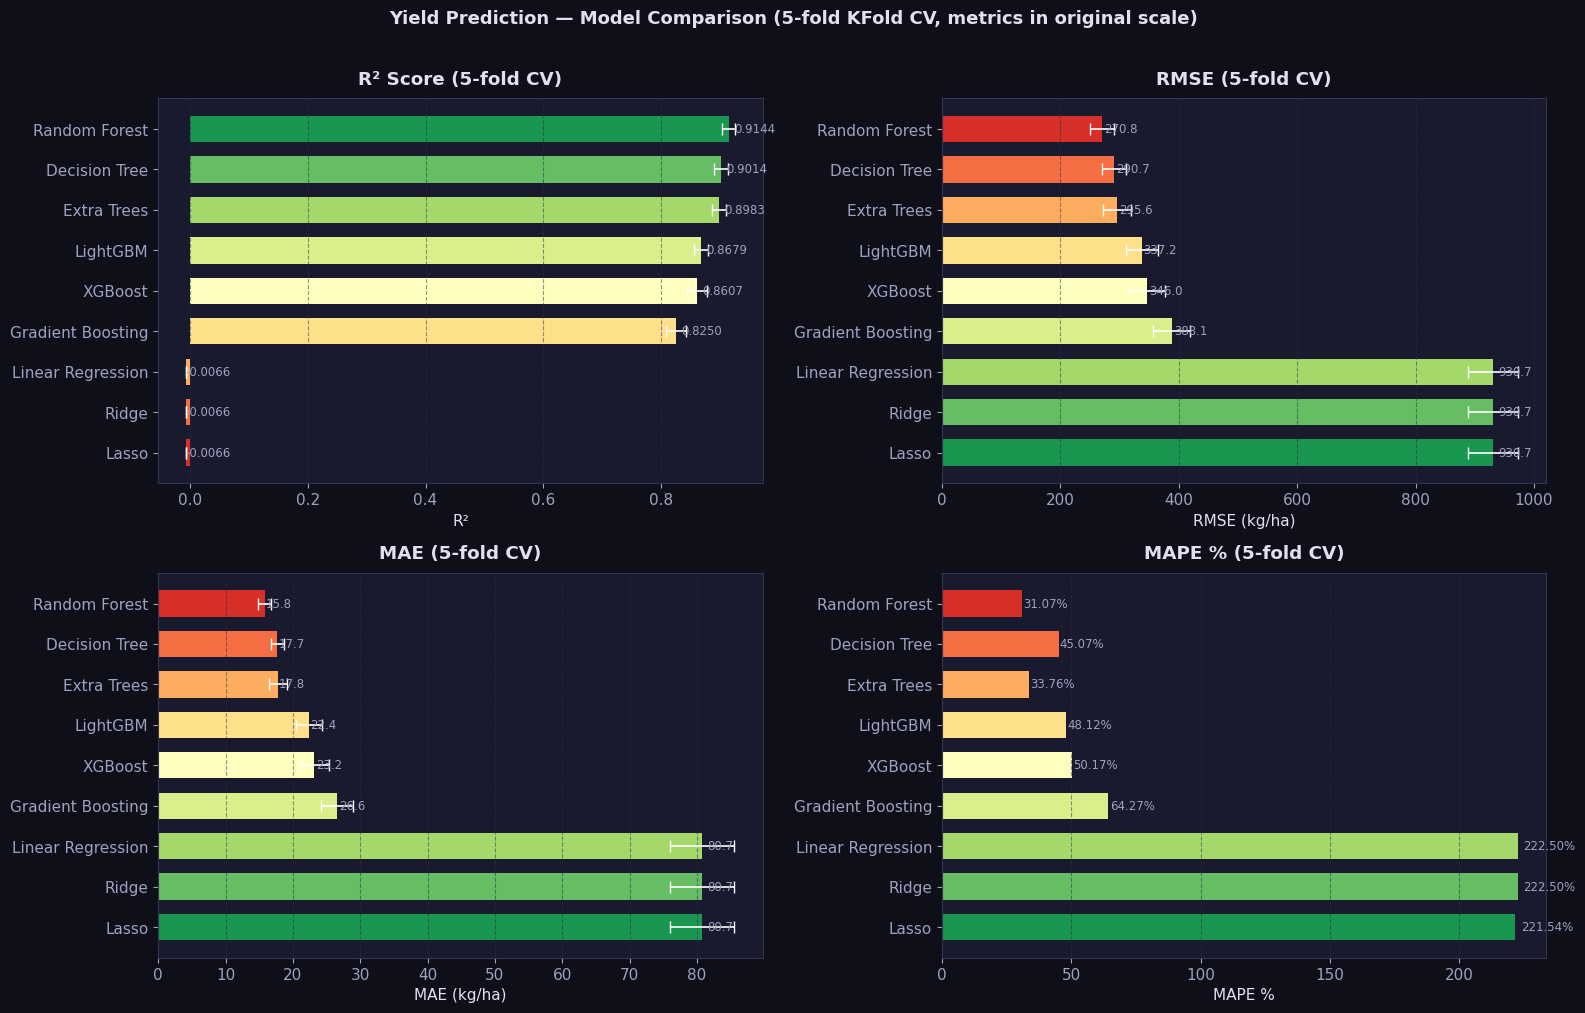

In [9]:
model_names = res_df.index.tolist()
r2_vals     = res_df['R2'].values
rmse_vals   = res_df['RMSE'].values
mae_vals    = res_df['MAE'].values
mape_vals   = res_df['MAPE'].values

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

def hbar(ax, vals, stds, title, xlabel, color, fmt='{:.4f}', invert=False):
    colors_g = plt.cm.RdYlGn(np.linspace(0.1, 0.9, len(model_names)))
    if invert: colors_g = colors_g[::-1]
    ax.barh(model_names[::-1], vals[::-1], color=colors_g, edgecolor='none', height=0.65)
    if stds is not None:
        ax.errorbar(vals[::-1], model_names[::-1], xerr=stds[::-1],
                    fmt='none', color='white', capsize=4, linewidth=1.2)
    for i, v in enumerate(vals[::-1]):
        ax.text(v * 1.01 if v > 0 else v - abs(v)*0.01, i, fmt.format(v),
                va='center', fontsize=8.5, color='#a0a0c0')
    ax.set_xlabel(xlabel)
    ax.set_title(title, fontweight='bold', pad=10)
    ax.grid(axis='x')

hbar(axes[0], r2_vals,   res_df['R2_std'].values,   'R² Score (5-fold CV)',      'R²',          'green')
hbar(axes[1], rmse_vals, res_df['RMSE_std'].values, 'RMSE (5-fold CV)',           'RMSE (kg/ha)','red', fmt='{:,.1f}', invert=True)
hbar(axes[2], mae_vals,  res_df['MAE_std'].values,  'MAE (5-fold CV)',            'MAE (kg/ha)', 'red', fmt='{:,.1f}', invert=True)
hbar(axes[3], mape_vals, None,                       'MAPE % (5-fold CV)',         'MAPE %',      'red', fmt='{:.2f}%', invert=True)

fig.suptitle('Yield Prediction — Model Comparison (5-fold KFold CV, metrics in original scale)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

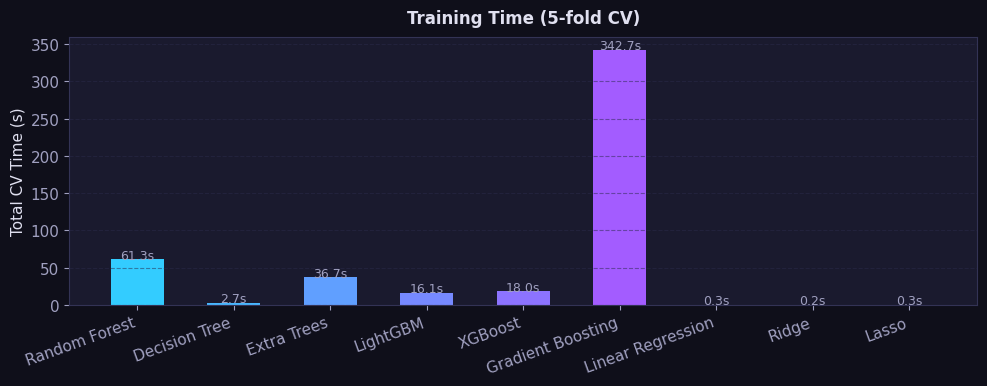

In [10]:
# Training time
fig, ax = plt.subplots(figsize=(10, 4))
times = res_df['Time (s)'].values
bar_colors = plt.cm.cool(np.linspace(0.2, 0.9, len(model_names)))
ax.bar(res_df.index, times, color=bar_colors, edgecolor='none', width=0.55)
for i, v in enumerate(times):
    ax.text(i, v + 0.5, f'{v:.1f}s', ha='center', fontsize=9, color='#a0a0c0')
ax.set_xticklabels(res_df.index, rotation=20, ha='right')
ax.set_ylabel('Total CV Time (s)')
ax.set_title('Training Time (5-fold CV)', fontsize=12, fontweight='bold', pad=10)
ax.grid(axis='y')
plt.tight_layout()
plt.show()

## 9. Select Best Model & Train on Full Train Set

In [11]:
best_name = res_df['R2'].idxmax()
print(f'🏆 Best model by CV R² : {best_name}')
print(f'   R²   = {res_df.loc[best_name, "R2"]:.4f} ± {res_df.loc[best_name, "R2_std"]:.4f}')
print(f'   RMSE = {res_df.loc[best_name, "RMSE"]:,.2f} ± {res_df.loc[best_name, "RMSE_std"]:,.2f}')
print(f'   MAE  = {res_df.loc[best_name, "MAE"]:,.2f} ± {res_df.loc[best_name, "MAE_std"]:,.2f}')
print(f'   MAPE = {res_df.loc[best_name, "MAPE"]:.2f}%')

best_model = models[best_name]
t0 = time.time()
best_model.fit(X_train, y_train_log)
print(f'\nFitted on full train in {time.time()-t0:.1f}s')

🏆 Best model by CV R² : Random Forest
   R²   = 0.9144 ± 0.0110
   RMSE = 270.82 ± 20.65
   MAE  = 15.83 ± 0.95
   MAPE = 31.07%

Fitted on full train in 19.6s


## 10. Test Set Evaluation

In [13]:
y_pred_log  = best_model.predict(X_test)
y_pred_orig = np.expm1(np.clip(y_pred_log, None, 15))  # clip extreme log vals

test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_orig))
test_mae  = mean_absolute_error(y_test, y_pred_orig)
test_r2   = r2_score(y_test, y_pred_orig)
nonzero   = y_test > 0
test_mape = np.mean(np.abs((y_test[nonzero] - y_pred_orig[nonzero]) / y_test[nonzero])) * 100

print(f'=== {best_name} — Test Set Results ===')
print(f'  R²         : {test_r2:.4f}')
print(f'  RMSE       : {test_rmse:,.2f} kg/ha')
print(f'  MAE        : {test_mae:,.2f} kg/ha')
print(f'  MAPE       : {test_mape:.2f}%')

=== Random Forest — Test Set Results ===
  R²         : 0.9149
  RMSE       : 265.09 kg/ha
  MAE        : 15.00 kg/ha
  MAPE       : 31.33%


## 11. Actual vs Predicted Plot

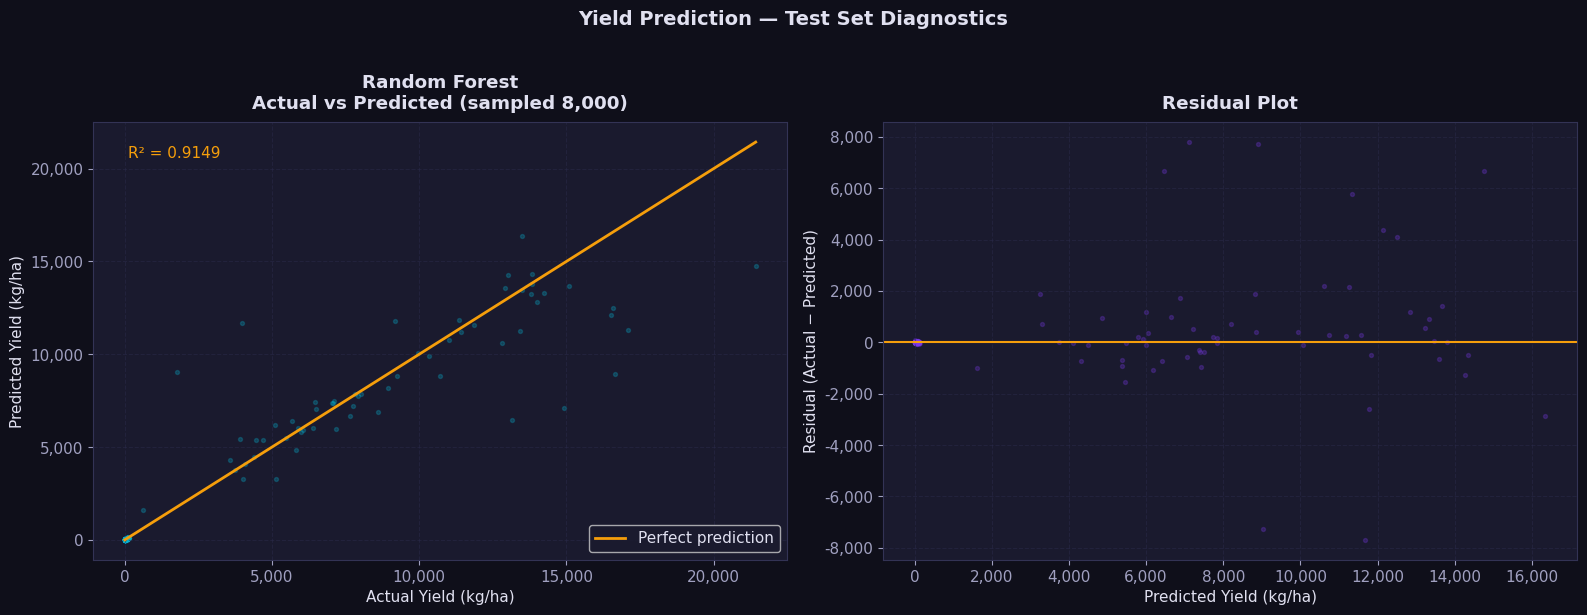

In [14]:
sample_n = min(8000, len(y_test))
idx = np.random.default_rng(42).choice(len(y_test), sample_n, replace=False)
y_t_s = y_test[idx]
y_p_s = y_pred_orig[idx]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Scatter
axes[0].scatter(y_t_s, y_p_s, alpha=0.25, s=8, color=ACCENT2)
max_val = max(y_t_s.max(), y_p_s.max())
axes[0].plot([0, max_val], [0, max_val], color=HIGHLIGHT, linewidth=2, label='Perfect prediction')
axes[0].set_xlabel('Actual Yield (kg/ha)')
axes[0].set_ylabel('Predicted Yield (kg/ha)')
axes[0].set_title(f'{best_name}\nActual vs Predicted (sampled {sample_n:,})',
                  fontweight='bold', pad=10)
axes[0].legend()
axes[0].grid(True)
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
axes[0].text(0.05, 0.92, f'R² = {test_r2:.4f}', transform=axes[0].transAxes,
             fontsize=11, color=HIGHLIGHT)

# Residuals
residuals = y_t_s - y_p_s
axes[1].scatter(y_p_s, residuals, alpha=0.25, s=8, color=ACCENT)
axes[1].axhline(0, color=HIGHLIGHT, linewidth=1.5)
axes[1].set_xlabel('Predicted Yield (kg/ha)')
axes[1].set_ylabel('Residual (Actual − Predicted)')
axes[1].set_title('Residual Plot', fontweight='bold', pad=10)
axes[1].grid(True)
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

fig.suptitle('Yield Prediction — Test Set Diagnostics', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 12. Residual Distribution

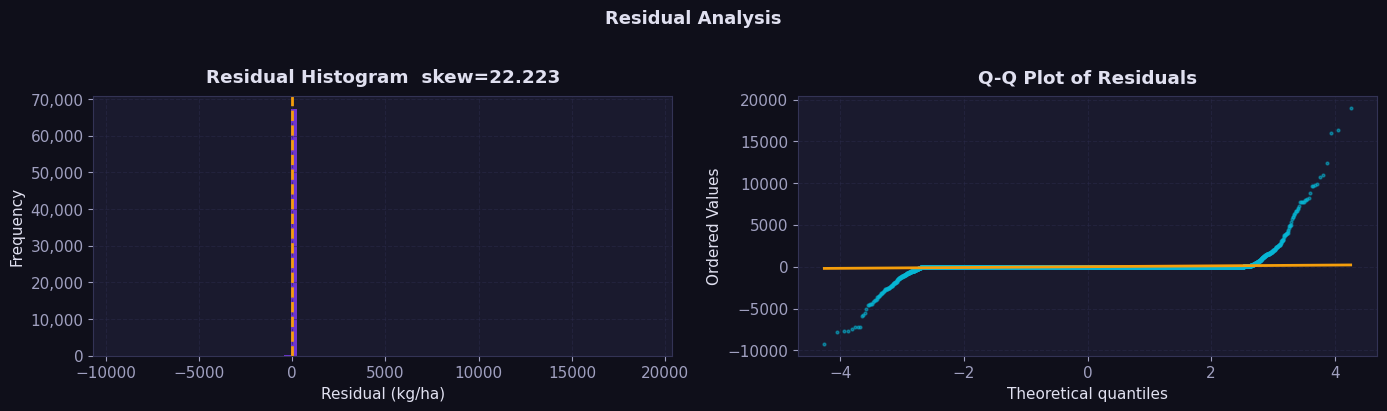

In [15]:
all_residuals = y_test - y_pred_orig

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(all_residuals, bins=80, color=ACCENT, edgecolor='none', alpha=0.85)
axes[0].axvline(0, color=HIGHLIGHT, linewidth=2, linestyle='--')
axes[0].set_xlabel('Residual (kg/ha)')
axes[0].set_ylabel('Frequency')
axes[0].set_title(f'Residual Histogram  skew={pd.Series(all_residuals).skew():.3f}',
                  fontweight='bold', pad=10)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
axes[0].grid(True)

from scipy import stats as sp_stats
sp_stats.probplot(all_residuals, dist='norm', plot=axes[1])
axes[1].get_lines()[0].set(color=ACCENT2, alpha=0.5, markersize=2)
axes[1].get_lines()[1].set(color=HIGHLIGHT, linewidth=2)
axes[1].set_title('Q-Q Plot of Residuals', fontweight='bold', pad=10)
axes[1].grid(True)

fig.suptitle('Residual Analysis', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 13. Feature Importance

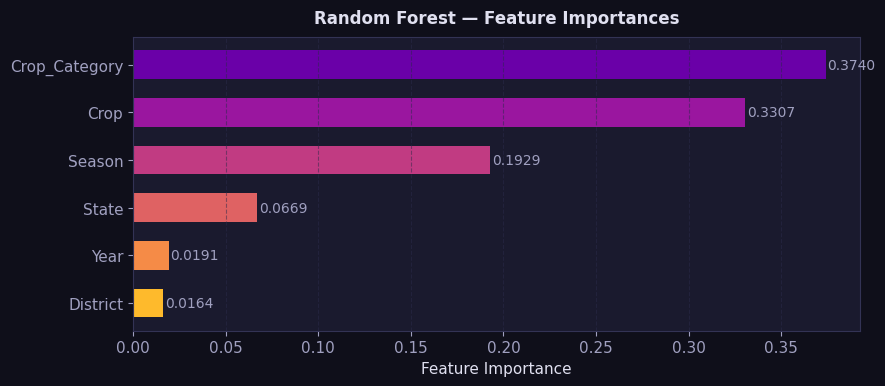


Feature Importance Table:
      Feature  Importance
Crop_Category      0.3740
         Crop      0.3307
       Season      0.1929
        State      0.0669
         Year      0.0191
     District      0.0164


In [16]:
feature_names = CAT_FEATURES + NUM_FEATURES

if hasattr(best_model, 'feature_importances_'):
    importances = best_model.feature_importances_
    fi_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
    fi_df = fi_df.sort_values('Importance', ascending=False)

    fig, ax = plt.subplots(figsize=(9, 4))
    colors_fi = plt.cm.plasma(np.linspace(0.85, 0.2, len(fi_df)))
    ax.barh(fi_df['Feature'][::-1], fi_df['Importance'][::-1],
            color=colors_fi, edgecolor='none', height=0.6)
    for i, v in enumerate(fi_df['Importance'].values[::-1]):
        ax.text(v + 0.001, i, f'{v:.4f}', va='center', fontsize=10, color='#a0a0c0')
    ax.set_xlabel('Feature Importance')
    ax.set_title(f'{best_name} — Feature Importances', fontsize=12, fontweight='bold', pad=10)
    ax.grid(axis='x')
    plt.tight_layout()
    plt.show()

    print('\nFeature Importance Table:')
    print(fi_df.to_string(index=False))

elif hasattr(best_model, 'coef_'):
    fi_df = pd.DataFrame({'Feature': feature_names, 'Coefficient': best_model.coef_})
    fi_df = fi_df.reindex(fi_df['Coefficient'].abs().sort_values(ascending=False).index)
    print('Linear model coefficients:')
    print(fi_df.to_string(index=False))
else:
    print('Feature importance not available.')

## 14. Error by Season & State

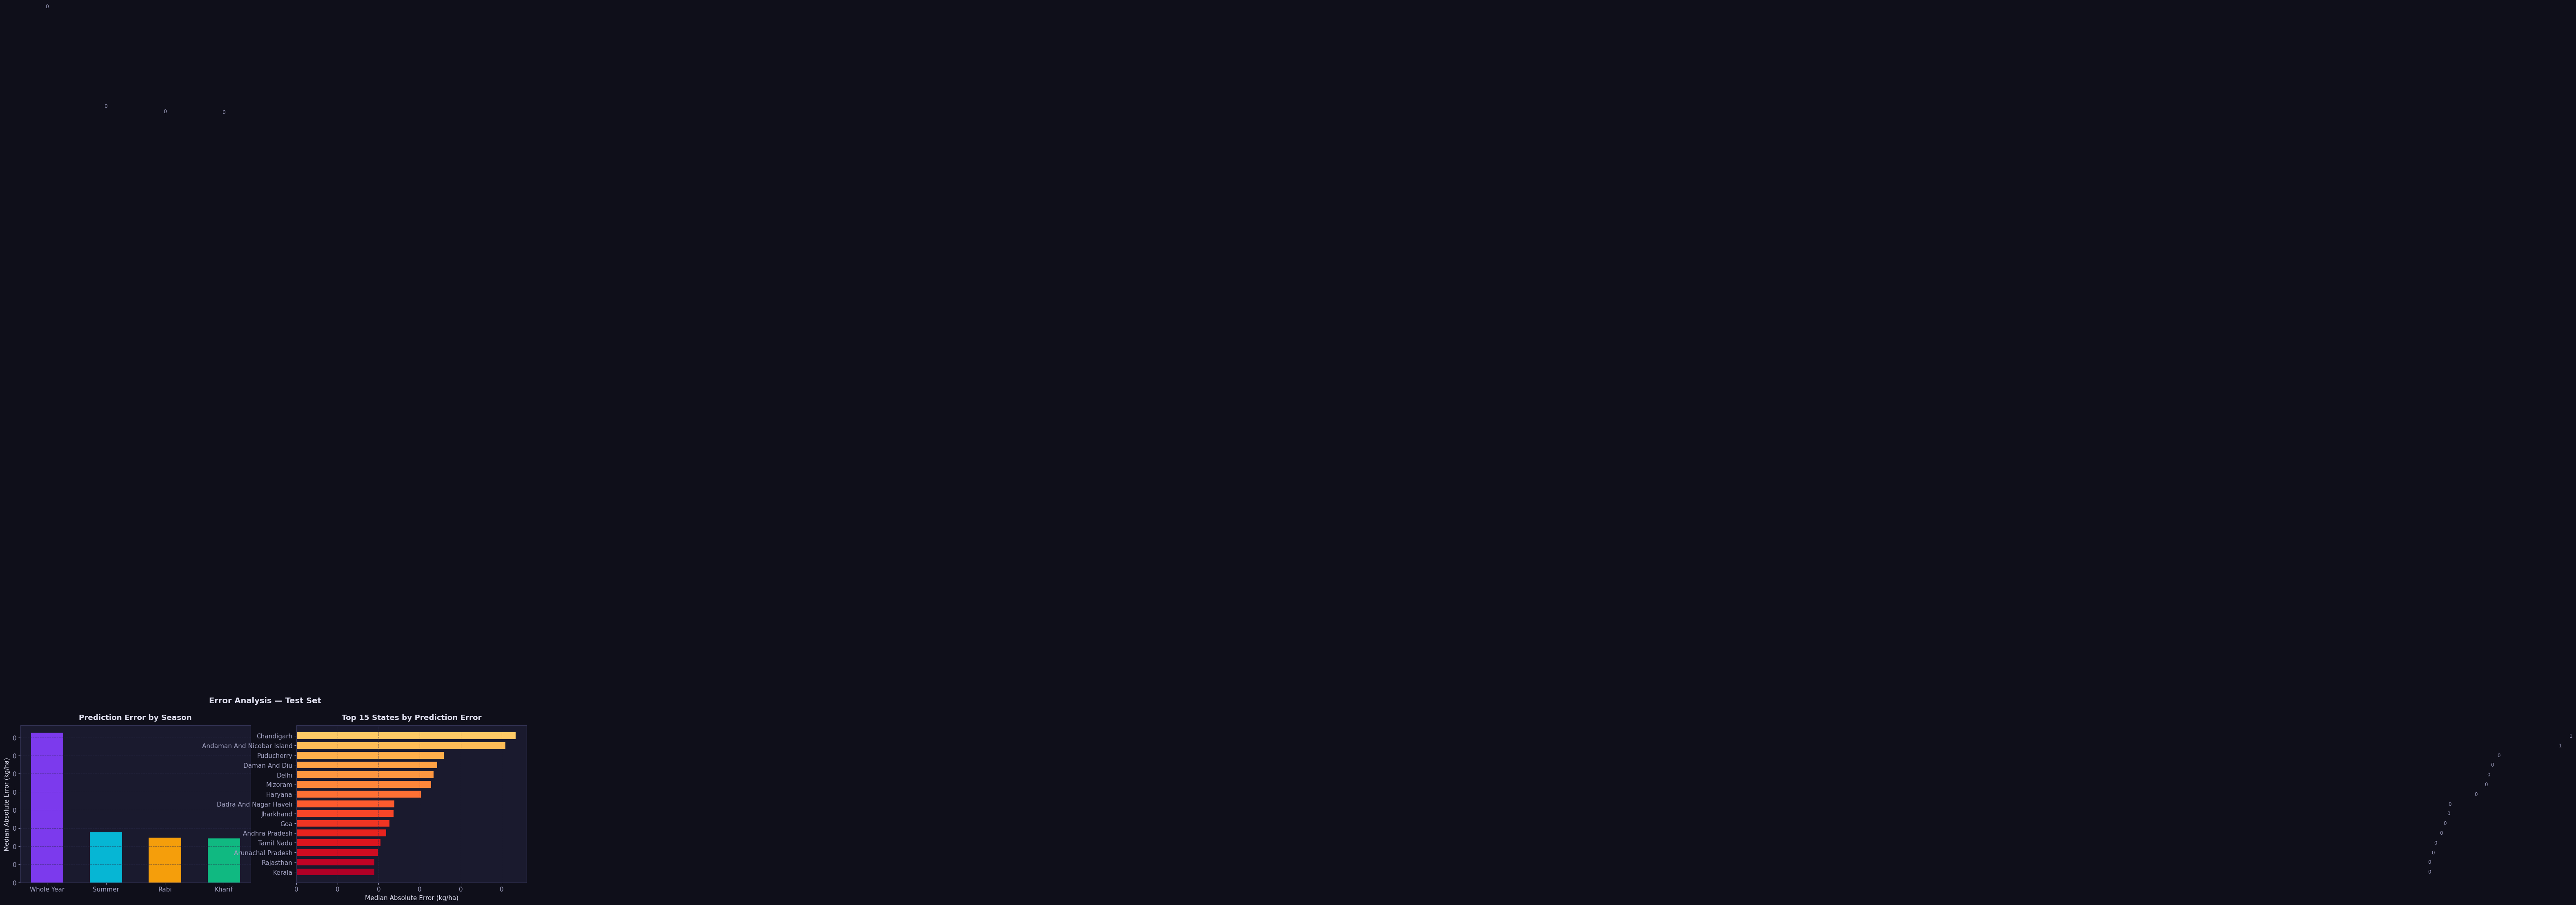

In [17]:
test_results_df = test.copy()
test_results_df['Predicted'] = y_pred_orig
test_results_df['AbsError']  = np.abs(test_results_df['Yield'] - test_results_df['Predicted'])
test_results_df['MAPE']      = np.where(
    test_results_df['Yield'] > 0,
    np.abs((test_results_df['Yield'] - test_results_df['Predicted']) / test_results_df['Yield']) * 100,
    np.nan
)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# MAE by Season
season_err = test_results_df.groupby('Season')['AbsError'].median().sort_values(ascending=False)
season_colors = [ACCENT, ACCENT2, HIGHLIGHT, GREEN]
axes[0].bar(season_err.index, season_err.values,
            color=season_colors[:len(season_err)], edgecolor='none', width=0.55)
for i, v in enumerate(season_err.values):
    axes[0].text(i, v + 2, f'{v:,.0f}', ha='center', fontsize=9, color='#a0a0c0')
axes[0].set_ylabel('Median Absolute Error (kg/ha)')
axes[0].set_title('Prediction Error by Season', fontweight='bold', pad=10)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
axes[0].grid(axis='y')

# MAE by Top 15 States
state_err = test_results_df.groupby('State')['AbsError'].median().sort_values(ascending=False).head(15)
colors_se = plt.cm.YlOrRd(np.linspace(0.9, 0.3, len(state_err)))
axes[1].barh(state_err.index[::-1], state_err.values[::-1], color=colors_se, edgecolor='none', height=0.7)
for i, v in enumerate(state_err.values[::-1]):
    axes[1].text(v + 5, i, f'{v:,.0f}', va='center', fontsize=8.5, color='#a0a0c0')
axes[1].set_xlabel('Median Absolute Error (kg/ha)')
axes[1].set_title('Top 15 States by Prediction Error', fontweight='bold', pad=10)
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
axes[1].grid(axis='x')

fig.suptitle('Error Analysis — Test Set', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 15. Model Comparison Radar Chart

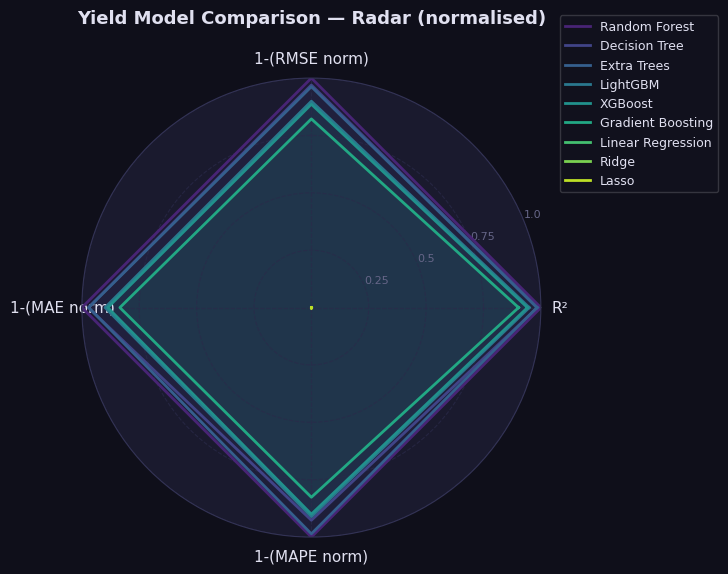

In [18]:
# Normalise all metrics to [0,1] (higher = better)
radar_metrics = ['R2', 'RMSE', 'MAE', 'MAPE']
radar_labels  = ['R²', '1-(RMSE norm)', '1-(MAE norm)', '1-(MAPE norm)']

rdf = res_df[radar_metrics].copy()
# For error metrics: invert so higher = better
for col in ['RMSE', 'MAE', 'MAPE']:
    rdf[col] = 1 - (rdf[col] - rdf[col].min()) / (rdf[col].max() - rdf[col].min() + 1e-9)
# R² already: higher is better; normalise to [0,1] if min < 0
r2_min = rdf['R2'].min()
rdf['R2'] = (rdf['R2'] - r2_min) / (rdf['R2'].max() - r2_min + 1e-9)

N = len(radar_labels)
angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
ax.set_facecolor('#1a1a2e'); fig.patch.set_facecolor('#0f0f1a')

colors_r = plt.cm.viridis(np.linspace(0.1, 0.9, len(rdf)))
for i, (name, row) in enumerate(rdf.iterrows()):
    vals = row[radar_metrics].tolist() + [row[radar_metrics[0]]]
    ax.plot(angles, vals, color=colors_r[i], linewidth=2, label=name)
    ax.fill(angles, vals, color=colors_r[i], alpha=0.07)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(radar_labels, fontsize=11, color='#e0e0f0')
ax.set_ylim(0, 1)
ax.set_yticks([0.25, 0.5, 0.75, 1.0])
ax.set_yticklabels(['0.25', '0.5', '0.75', '1.0'], fontsize=8, color='#666688')
ax.grid(color='#2a2a4a', linestyle='--', alpha=0.7)
ax.set_title('Yield Model Comparison — Radar (normalised)', pad=20, fontsize=13, fontweight='bold', color='#e0e0f0')
ax.legend(loc='upper right', bbox_to_anchor=(1.40, 1.15), fontsize=9,
          framealpha=0.2, labelcolor='#e0e0f0')
plt.tight_layout()
plt.show()

## 16. Save Summary

In [19]:
os.makedirs('../outputs', exist_ok=True)

summary = f"""
========================================================
  YIELD PREDICTION — MODEL SELECTION SUMMARY
========================================================
Task            : Regression
Target          : Yield (kg/ha)  [log-transformed for training]
Features        : {FEATURES}
Train samples   : {len(train):,}
Test  samples   : {len(test):,}
CV Strategy     : KFold (5 folds)
Encoding        : OrdinalEncoder (categorical)

--- CV Results (sorted by R²) ---
{res_df[['R2','R2_std','RMSE','RMSE_std','MAE','MAE_std','MAPE','Time (s)']].to_string()}

--- Best Model ---
Name            : {best_name}
Test R²         : {test_r2:.4f}
Test RMSE       : {test_rmse:,.2f} kg/ha
Test MAE        : {test_mae:,.2f} kg/ha
Test MAPE       : {test_mape:.2f}%

--- Recommendations ---
1. Use {best_name} as the yield prediction model.
2. Apply log1p transform on Yield before training.
3. Apply expm1 to convert predictions back to kg/ha.
4. Area and Crop are the most informative features (check FI above).
5. Consider further hyperparameter tuning with Optuna.
========================================================
"""

out_path = '../outputs/yield_model_selection_summary.txt'
with open(out_path, 'w') as f:
    f.write(summary)

print(summary)
print(f'Summary saved → {os.path.abspath(out_path)}')


  YIELD PREDICTION — MODEL SELECTION SUMMARY
Task            : Regression
Target          : Yield (kg/ha)  [log-transformed for training]
Features        : ['State', 'District', 'Crop', 'Crop_Category', 'Season', 'Year']
Train samples   : 271,481
Test  samples   : 67,871
CV Strategy     : KFold (5 folds)
Encoding        : OrdinalEncoder (categorical)

--- CV Results (sorted by R²) ---
                       R2  R2_std     RMSE  RMSE_std     MAE  MAE_std     MAPE  Time (s)
Random Forest      0.9144  0.0110 270.8242   20.6487 15.8275   0.9526  31.0704   61.2736
Decision Tree      0.9014  0.0113 290.7135   19.9278 17.6559   0.9470  45.0735    2.6755
Extra Trees        0.8983  0.0118 295.5979   23.4703 17.7571   1.3173  33.7622   36.7126
LightGBM           0.8679  0.0121 337.2491   27.0983 22.3806   1.9490  48.1183   16.0831
XGBoost            0.8607  0.0172 346.0228   30.5615 23.1569   2.1396  50.1657   17.9863
Gradient Boosting  0.8250  0.0170 388.1138   31.6775 26.5713   2.3489  64.274